# LightGBM Only - Network Slicing 5G

This notebook trains and evaluates only a LightGBM multiclass model on the 5G network slicing dataset.

In [1]:
# Uncomment if needed
!pip install kagglehub lightgbm

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score

In [3]:
# Load dataset
path = kagglehub.dataset_download("amohankumar/network-slicing-in-5g")
df = pd.read_csv(path + "/train_dataset.csv")
print("Path to dataset files:", path)
print("Data shape:", df.shape)
df.head()

100%|██████████| 250k/250k [00:00<00:00, 479kB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/amohankumar/network-slicing-in-5g/versions/1
Data shape: (31583, 17)


,LTE/5g Category,Time,Packet Loss Rate,Packet delay,IoT,LTE/5G,GBR,Non-GBR,AR/VR/Gaming,Healthcare,Industry 4.0,IoT Devices,Public Safety,Smart City & Home,Smart Transportation,Smartphone,slice Type
0,14,0,0.000001,10,1,0,0,1,0,0,0,0,1,0,0,0,3
1,18,20,0.001000,100,0,1,1,0,1,0,0,0,0,0,0,0,1
2,17,14,0.000001,300,0,1,0,1,0,0,0,0,0,0,0,1,1
3,3,17,0.010000,100,0,1,0,1,0,0,0,0,0,0,0,1,1
4,9,4,0.010000,50,1,0,0,1,0,0,0,0,0,1,0,0,2


In [4]:
# Keep only selected features and target
selected_features = [
    "LTE/5g Category",
    "Packet Loss Rate",
    "Packet delay",
    "Smartphone",
    "IoT Devices",
    "GBR"
]
target_col = "slice Type"

X = df[selected_features].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=12,
    stratify=y
)

# Label encode target for multiclass LightGBM
label_encoder = LabelEncoder()
y_train_lgbm = label_encoder.fit_transform(np.asarray(y_train).ravel())
y_test_lgbm = label_encoder.transform(np.asarray(y_test).ravel())

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Classes:", label_encoder.classes_)

X_train shape: (22108, 6)
X_test shape: (9475, 6)
Classes: [1 2 3]


In [5]:
# Train/evaluate across different n_estimators
params = [5, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40]

train_accuracy_scores = []
test_accuracy_scores = []
train_precision_scores = []
test_precision_scores = []
train_recall_scores = []
test_recall_scores = []
train_f1_scores = []
test_f1_scores = []
exec_times = []

num_classes_lgbm = len(np.unique(y_train_lgbm))

for n_estimators_val in params:
    start_time = time.time()

    model = lgb.LGBMClassifier(
        objective="multiclass",
        num_class=num_classes_lgbm,
        n_estimators=n_estimators_val,
        max_depth=3,
        colsample_bytree=0.33,
        reg_lambda=15.0,
        random_state=12,
        verbose=-1
    )

    model.fit(X_train, y_train_lgbm)
    exec_time = time.time() - start_time

    train_accuracy = model.score(X_train, y_train_lgbm)
    test_accuracy = model.score(X_test, y_test_lgbm)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_precision = precision_score(y_train_lgbm, y_train_pred, average="weighted", zero_division=0)
    test_precision = precision_score(y_test_lgbm, y_test_pred, average="weighted", zero_division=0)
    train_recall = recall_score(y_train_lgbm, y_train_pred, average="weighted", zero_division=0)
    test_recall = recall_score(y_test_lgbm, y_test_pred, average="weighted", zero_division=0)
    train_f1 = f1_score(y_train_lgbm, y_train_pred, average="weighted", zero_division=0)
    test_f1 = f1_score(y_test_lgbm, y_test_pred, average="weighted", zero_division=0)

    train_accuracy_scores.append(train_accuracy)
    test_accuracy_scores.append(test_accuracy)
    train_precision_scores.append(train_precision)
    test_precision_scores.append(test_precision)
    train_recall_scores.append(train_recall)
    test_recall_scores.append(test_recall)
    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)
    exec_times.append(exec_time)

    print(f"n_estimators = {n_estimators_val}")
    print(f"  Train -> Acc: {train_accuracy:.4f} | Prec: {train_precision:.4f} | Rec: {train_recall:.4f} | F1: {train_f1:.4f}")
    print(f"  Test  -> Acc: {test_accuracy:.4f} | Prec: {test_precision:.4f} | Rec: {test_recall:.4f} | F1: {test_f1:.4f}")
    print(f"  Time: {exec_time:.4f} s")
    print("-" * 70)

results_df = pd.DataFrame({
    "n_estimators": params,
    "train_accuracy": train_accuracy_scores,
    "test_accuracy": test_accuracy_scores,
    "train_precision": train_precision_scores,
    "test_precision": test_precision_scores,
    "train_recall": train_recall_scores,
    "test_recall": test_recall_scores,
    "train_f1": train_f1_scores,
    "test_f1": test_f1_scores,
    "exec_time_s": exec_times
})

results_df

n_estimators = 5
  Train -> Acc: 0.8296 | Prec: 0.8709 | Rec: 0.8296 | F1: 0.7925
  Test  -> Acc: 0.8285 | Prec: 0.8703 | Rec: 0.8285 | F1: 0.7908
  Time: 0.2708 s
----------------------------------------------------------------------
n_estimators = 10
  Train -> Acc: 0.8934 | Prec: 0.9112 | Rec: 0.8934 | F1: 0.8825
  Test  -> Acc: 0.8926 | Prec: 0.9106 | Rec: 0.8926 | F1: 0.8815
  Time: 0.2105 s
----------------------------------------------------------------------
n_estimators = 12
  Train -> Acc: 0.8934 | Prec: 0.9112 | Rec: 0.8934 | F1: 0.8825
  Test  -> Acc: 0.8926 | Prec: 0.9106 | Rec: 0.8926 | F1: 0.8815
  Time: 0.2360 s
----------------------------------------------------------------------
n_estimators = 14
  Train -> Acc: 0.9477 | Prec: 0.9524 | Rec: 0.9477 | F1: 0.9456
  Test  -> Acc: 0.9506 | Prec: 0.9548 | Rec: 0.9506 | F1: 0.9488
  Time: 0.3183 s
----------------------------------------------------------------------
n_estimators = 16
  Train -> Acc: 0.9450 | Prec: 0.9554 |

,n_estimators,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,exec_time_s
0,5,0.829564,0.828496,0.870924,0.870311,0.829564,0.828496,0.792547,0.790794,0.270761
1,10,0.893387,0.892559,0.911189,0.910614,0.893387,0.892559,0.882524,0.881478,0.210550
2,12,0.893387,0.892559,0.911189,0.910614,0.893387,0.892559,0.882524,0.881478,0.235955
3,14,0.947711,0.950607,0.952392,0.954804,0.947711,0.950607,0.945649,0.948788,0.318344
4,16,0.944952,0.947968,0.955433,0.957434,0.944952,0.947968,0.946346,0.949234,0.154929
5,18,0.944952,0.947968,0.955433,0.957434,0.944952,0.947968,0.946346,0.949234,0.201084
6,20,0.944952,0.947968,0.955433,0.957434,0.944952,0.947968,0.946346,0.949234,0.319070
7,25,0.944952,0.947968,0.955433,0.957434,0.944952,0.947968,0.946346,0.949234,0.282013
8,30,0.944952,0.947968,0.955433,0.957434,0.944952,0.947968,0.946346,0.949234,0.366709
9,35,0.997919,0.996939,0.997938,0.996979,0.997919,0.996939,0.997922,0.996945,0.604065


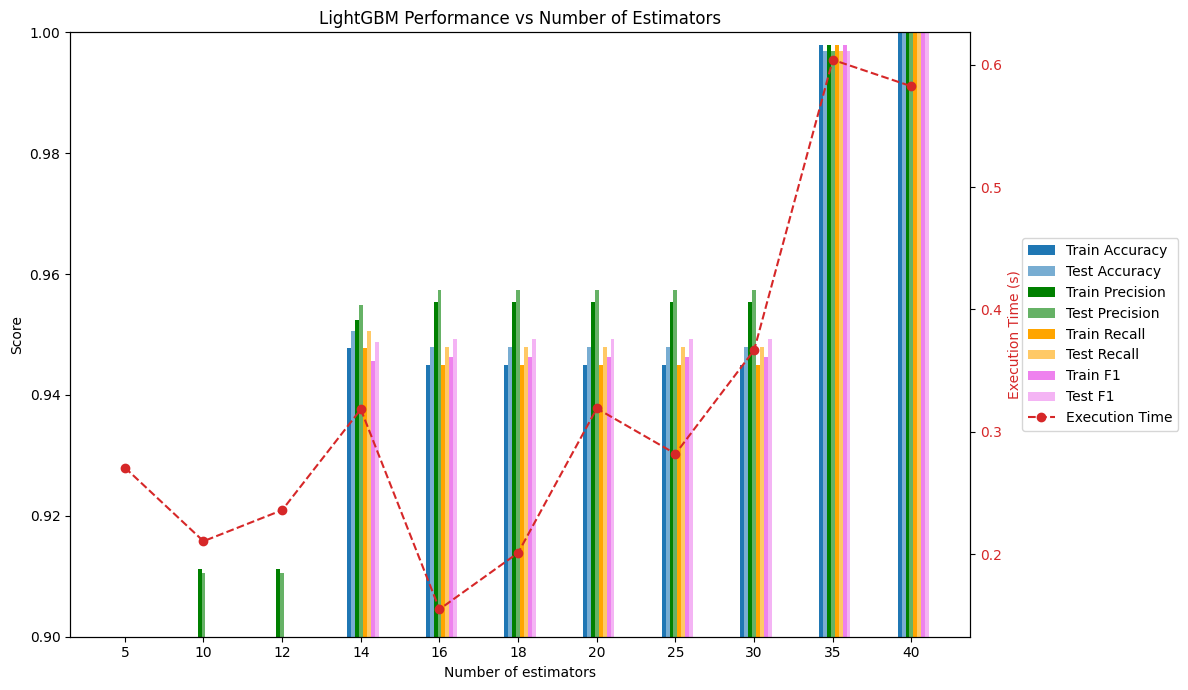

In [6]:
# Plot metrics and execution time
fig, ax1 = plt.subplots(figsize=(12, 7))
positions = np.arange(len(params))
bar_width = 0.05

ax1.bar(positions - 3 * bar_width, train_accuracy_scores, width=bar_width, color="tab:blue", label="Train Accuracy")
ax1.bar(positions - 2 * bar_width, test_accuracy_scores, width=bar_width, color="tab:blue", alpha=0.6, label="Test Accuracy")
ax1.bar(positions - bar_width, train_precision_scores, width=bar_width, color="green", label="Train Precision")
ax1.bar(positions, test_precision_scores, width=bar_width, color="green", alpha=0.6, label="Test Precision")
ax1.bar(positions + bar_width, train_recall_scores, width=bar_width, color="orange", label="Train Recall")
ax1.bar(positions + 2 * bar_width, test_recall_scores, width=bar_width, color="orange", alpha=0.6, label="Test Recall")
ax1.bar(positions + 3 * bar_width, train_f1_scores, width=bar_width, color="violet", label="Train F1")
ax1.bar(positions + 4 * bar_width, test_f1_scores, width=bar_width, color="violet", alpha=0.6, label="Test F1")

ax1.set_xticks(positions)
ax1.set_xticklabels(params)
ax1.set_xlabel("Number of estimators")
ax1.set_ylabel("Score")
ax1.set_ylim([0.90, 1.00])

ax2 = ax1.twinx()
ax2.plot(positions, exec_times, color="tab:red", marker="o", linestyle="--", label="Execution Time")
ax2.set_ylabel("Execution Time (s)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="center left", bbox_to_anchor=(1.05, 0.5))

plt.title("LightGBM Performance vs Number of Estimators")
fig.tight_layout()
plt.show()

In [7]:
best_idx = int(np.argmax(results_df["test_accuracy"].values))
best_row = results_df.iloc[best_idx]

print("Best configuration by test accuracy:")
print(best_row.to_string())

Best configuration by test accuracy:
n_estimators       40.000000
train_accuracy      1.000000
test_accuracy       1.000000
train_precision     1.000000
test_precision      1.000000
train_recall        1.000000
test_recall         1.000000
train_f1            1.000000
test_f1             1.000000
exec_time_s         0.582395


In [9]:
import lightgbm as lgb

model_final = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=num_classes_lgbm,
    n_estimators=20,           # وقفناه في الـ Sweet Spot!
    learning_rate=0.05,
    max_depth=3,
    colsample_bytree=0.33,
    reg_lambda=15.0,
    random_state=12,
    verbose=-1
)

model_final.fit(X_train, y_train_lgbm)


LGBMClassifier(colsample_bytree=0.33, learning_rate=0.05, max_depth=3,
               n_estimators=20, num_class=3, objective='multiclass',
               random_state=12, reg_lambda=15.0, verbose=-1)

RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

        eMBB       0.83      1.00      0.91      5040
        mMTC       1.00      0.54      0.70      2217
       URLLC       1.00      1.00      1.00      2218

    accuracy                           0.89      9475
   macro avg       0.94      0.85      0.87      9475
weighted avg       0.91      0.89      0.88      9475



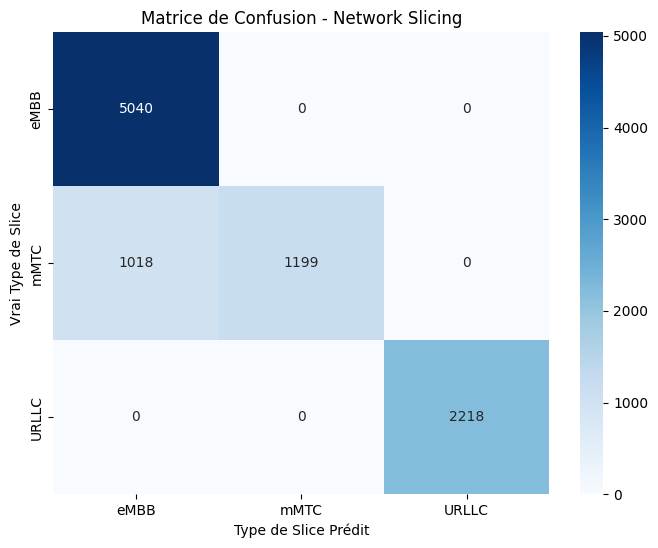

IMPORTANCE DES FEATURES


/tmp/ipykernel_8361/1470920697.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Valeur", y="Feature", data=feature_imp, palette="viridis")


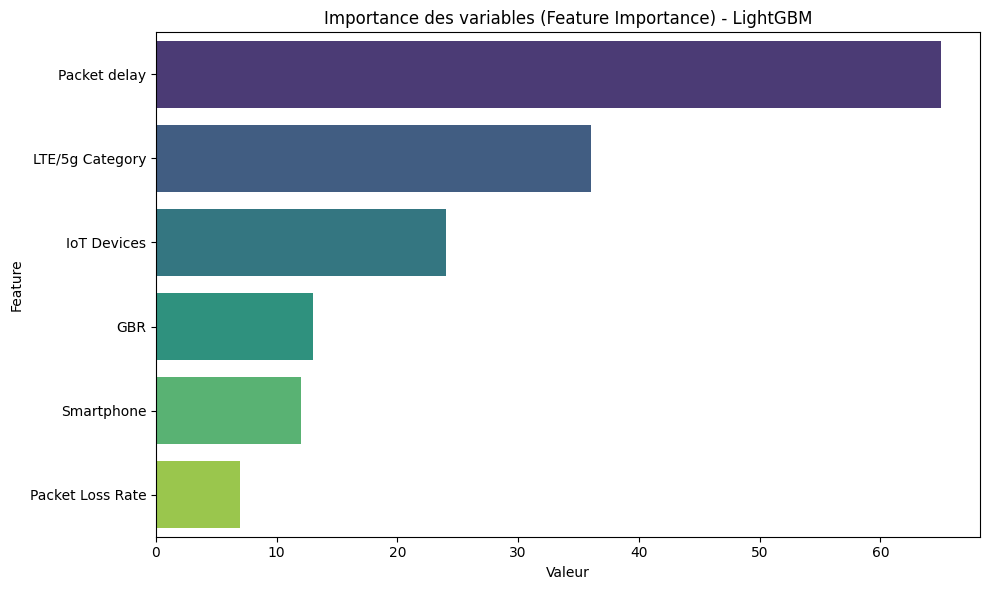

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

y_pred = model_final.predict(X_test)

class_names = ['eMBB', 'mMTC', 'URLLC']

print("="*50)
print("RAPPORT DE CLASSIFICATION")
print("="*50)
print(classification_report(y_test_lgbm, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_test_lgbm, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - Network Slicing')
plt.ylabel('Vrai Type de Slice')
plt.xlabel('Type de Slice Prédit')
plt.show()

print("="*50)
print("IMPORTANCE DES FEATURES")
print("="*50)

feature_imp = pd.DataFrame(
    {'Valeur': model_final.feature_importances_ ,
     'Feature': X_train.columns}
)

feature_imp = feature_imp.sort_values(by="Valeur", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Valeur", y="Feature", data=feature_imp, palette="viridis")
plt.title("Importance des variables (Feature Importance) - LightGBM")
plt.tight_layout()
plt.show()

---
## Explainability — SHAP

> *DSO : "Model Interpretability and Explainable AI (XAI)"*

SHAP (SHapley Additive exPlanations) permet d'expliquer **pourquoi** le modèle
LightGBM assigne une slice donnée (eMBB / mMTC / URLLC) à un flux réseau.

- **Summary Plot global** → quelles features influencent le plus le modèle toutes classes confondues
- **Beeswarm par classe** → impact de chaque feature spécifiquement pour eMBB, mMTC, URLLC
- **Force Plot** → explication d'une prédiction individuelle (un seul exemple)

✅ SHAP values shape (3D) : (9475, 6, 3)


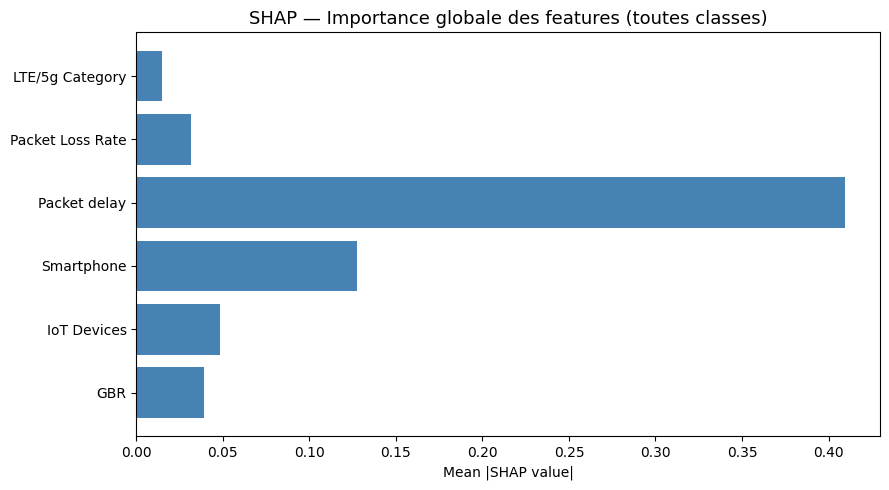

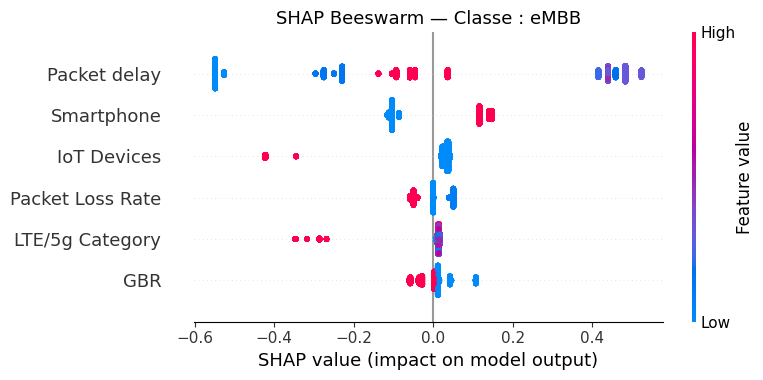

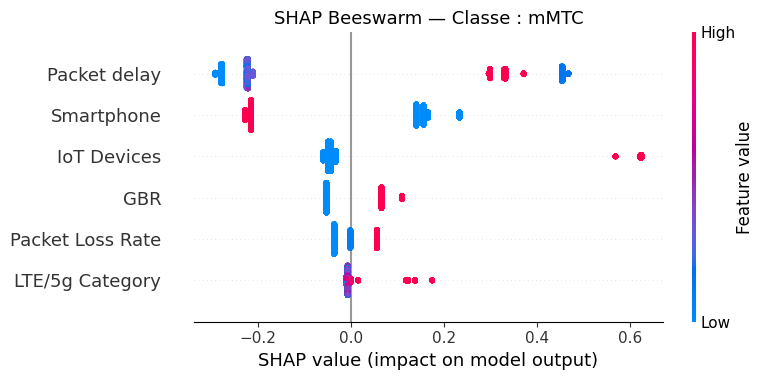

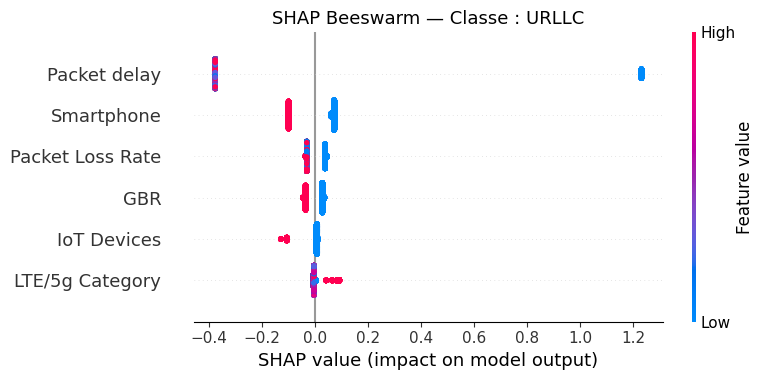


🔍 Exemple #0 → Slice prédite : eMBB


In [13]:
# ============================================================
# SHAP — Explainability du modèle LightGBM (CORRIGÉ)
# ============================================================

import shap
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Explainer ---
explainer  = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test)

# shap_values shape : (n_samples, n_features, n_classes)
print(f"✅ SHAP values shape (3D) : {shap_values.shape}")
# => attendu : (n_samples, 6, 3)

# Séparer par classe : shap_values[:, :, i] → (n_samples, n_features)
sv_embb  = shap_values[:, :, 0]
sv_mmtc  = shap_values[:, :, 1]
sv_urllc = shap_values[:, :, 2]

# --- 2. Summary Plot GLOBAL ---
shap_abs_mean = np.mean(np.abs(shap_values), axis=(0, 2))  # (n_features,)

plt.figure(figsize=(9, 5))
plt.barh(selected_features, shap_abs_mean, color="steelblue")
plt.xlabel("Mean |SHAP value|")
plt.title("SHAP — Importance globale des features (toutes classes)", fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- 3. Beeswarm par classe ---
for sv, cls in zip([sv_embb, sv_mmtc, sv_urllc], class_names):
    plt.figure(figsize=(9, 5))
    shap.summary_plot(
        sv,
        X_test,
        feature_names=selected_features,
        show=False
    )
    plt.title(f"SHAP Beeswarm — Classe : {cls}", fontsize=13)
    plt.tight_layout()
    plt.show()

# --- 4. Force Plot — un exemple individuel ---
sample_idx  = 0
pred_class  = int(model_final.predict(X_test.iloc[[sample_idx]])[0])
pred_label  = class_names[pred_class]

print(f"\n🔍 Exemple #{sample_idx} → Slice prédite : {pred_label}")

shap.initjs()
display(shap.force_plot(
    explainer.expected_value[pred_class],
    shap_values[sample_idx, :, pred_class],   # ← fix clé
    X_test.iloc[sample_idx],
    feature_names=selected_features
))